In [2]:
import pandas as pd

In [3]:
#Sherman Run
!unzip /content/feedback-prize-2021.zip -d /feedback-prize-2021

Streaming output truncated to the last 5000 lines.
  inflating: /feedback-prize-2021/train/AD7E8E2D63E3.txt  
  inflating: /feedback-prize-2021/train/AD802CC1863E.txt  
  inflating: /feedback-prize-2021/train/AD86E73E978B.txt  
  inflating: /feedback-prize-2021/train/AD8BBB12682E.txt  
  inflating: /feedback-prize-2021/train/AD968694871B.txt  
  inflating: /feedback-prize-2021/train/AD9CEE5A6FFF.txt  
  inflating: /feedback-prize-2021/train/AD9DF5656D88.txt  
  inflating: /feedback-prize-2021/train/ADA2D72FCD40.txt  
  inflating: /feedback-prize-2021/train/ADA5FE621125.txt  
  inflating: /feedback-prize-2021/train/ADA8F6319D6C.txt  
  inflating: /feedback-prize-2021/train/ADAE8A21CE9E.txt  
  inflating: /feedback-prize-2021/train/ADB29D5C3C55.txt  
  inflating: /feedback-prize-2021/train/ADB68BCD2874.txt  
  inflating: /feedback-prize-2021/train/ADBB29D9E179.txt  
  inflating: /feedback-prize-2021/train/ADC3C0B672FA.txt  
  inflating: /feedback-prize-2021/train/ADC46484D3B7.txt  
  inf

In [4]:
from pathlib import Path

# This automatically finds the train folder no matter where the zip was extracted
possible_paths = [
    Path('/content/feedback-prize-2021/train'),
    Path('/feedback-prize-2021/train'),
    Path('/content/train'),
    Path('feedback-prize-2021/train'),
    Path('/train'),
    Path('train'),
    Path('/zip/train')
]

folder_path = None
for p in possible_paths:
    if p.exists():
        folder_path = p
        print(f"Found data at: {folder_path}")
        break

if folder_path is None:
    print("Could not find the train folder! Please run the unzip command first.")
else:
    print(f"Using folder: {folder_path}")

Found data at: /feedback-prize-2021/train
Using folder: /feedback-prize-2021/train


In [5]:
import os
import pandas as pd
from pathlib import Path

# Update this to your folder name
folder_path = Path('/feedback-prize-2021/train') # Corrected path to where files were unzipped

# 1. Get a list of all files
files = list(folder_path.glob('*'))

# 2. Generate summary data
data = []
for f in files:
    data.append({
        'id': f.stem,           # Filename without extension
        'extension': f.suffix,  # .txt, etc.
        'size_bytes': f.stat().st_size
    })

df = pd.DataFrame(data)

# --- OUTPUTS ---
print(f"Total files found: {len(files)}")
print("\n--- File Extensions ---")
print(df['extension'].value_counts())

print("\n--- File Size Stats (Bytes) ---")
print(df['size_bytes'].describe())

print("\n--- First 5 IDs ---")
print(df['id'].head().tolist())

Total files found: 15594

--- File Extensions ---
extension
.txt    15594
Name: count, dtype: int64

--- File Size Stats (Bytes) ---
count    15594.000000
mean      2368.364563
std       1141.904998
min        691.000000
25%       1529.000000
50%       2137.500000
75%       2934.000000
max      20373.000000
Name: size_bytes, dtype: float64

--- First 5 IDs ---
['1449A333A335', '9CDFFD2C0726', '0D6EAC137920', '52A09816A434', '462F2BD14BDE']


In [6]:
train = pd.read_csv('/feedback-prize-2021/train.csv')
train.head(5)

,id,discourse_id,discourse_start,discourse_end,discourse_text,discourse_type,discourse_type_num,predictionstring
0,423A1CA112E2,1.622628e+12,8.0,229.0,Modern humans today are always on their phone....,Lead,Lead 1,1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 1...
1,423A1CA112E2,1.622628e+12,230.0,312.0,They are some really bad consequences when stu...,Position,Position 1,45 46 47 48 49 50 51 52 53 54 55 56 57 58 59
2,423A1CA112E2,1.622628e+12,313.0,401.0,Some certain areas in the United States ban ph...,Evidence,Evidence 1,60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75
3,423A1CA112E2,1.622628e+12,402.0,758.0,"When people have phones, they know about certa...",Evidence,Evidence 2,76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 9...
4,423A1CA112E2,1.622628e+12,759.0,886.0,Driving is one of the way how to get around. P...,Claim,Claim 1,139 140 141 142 143 144 145 146 147 148 149 15...


In [7]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# 1. Setup Paths
# Replace 'train_data' with the actual folder name you used when unzipping
DATA_DIR = Path('/feedback-prize-2021/train') # Corrected path to where files were unzipped
OUTPUT_FILE = 'train_full_texts.csv'

def create_text_csv(folder_path):
    # Get all .txt files in the directory
    text_files = list(folder_path.glob('*.txt'))

    print(f"Found {len(text_files)} files. Starting conversion...")

    # Read files into a list of dictionaries
    # 'stem' gives you the filename without the .txt extension
    data = []
    for file_path in tqdm(text_files):
        with open(file_path, 'r', encoding='utf-8') as f:
            data.append({
                'id': file_path.stem,
                'full_text': f.read()
            })

    # 2. Convert to DataFrame and Save
    df = pd.DataFrame(data)
    df.to_csv(OUTPUT_FILE, index=False)

    print(f"\nDone! Saved {len(df)} essays to {OUTPUT_FILE}")
    return df

# Execute
essay_df = create_text_csv(DATA_DIR)

Found 15594 files. Starting conversion...


100%|██████████| 15594/15594 [00:00<00:00, 44446.33it/s]



Done! Saved 15594 essays to train_full_texts.csv


In [8]:
train_data= pd.read_csv('train_full_texts.csv')
#train_data= pd.read_csv('train_full_texts.csv')
train_data.head(5)

,id,full_text
0,1449A333A335,The summer is a time for students to enjoy a b...
1,9CDFFD2C0726,"In ""Driverless Cars are Coming"" is a postive d..."
2,0D6EAC137920,"When you ask for advice, do you ask more than ..."
3,52A09816A434,"Throughout time, humans have sent numerous mis..."
4,462F2BD14BDE,"Dear Senator,\n\nDo you really think the elect..."


In [9]:
# 1. Load the labels
labels = pd.read_csv('/feedback-prize-2021/train.csv')

# 2. Merge them
# This will attach the full_text to every individual discourse segment row
train_master = labels.merge(train_data, on='id', how='left')

# 3. Check the result
train_master.head()

,id,discourse_id,discourse_start,discourse_end,discourse_text,discourse_type,discourse_type_num,predictionstring,full_text
0,423A1CA112E2,1.622628e+12,8.0,229.0,Modern humans today are always on their phone....,Lead,Lead 1,1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 1...,Phones\n\nModern humans today are always on th...
1,423A1CA112E2,1.622628e+12,230.0,312.0,They are some really bad consequences when stu...,Position,Position 1,45 46 47 48 49 50 51 52 53 54 55 56 57 58 59,Phones\n\nModern humans today are always on th...
2,423A1CA112E2,1.622628e+12,313.0,401.0,Some certain areas in the United States ban ph...,Evidence,Evidence 1,60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75,Phones\n\nModern humans today are always on th...
3,423A1CA112E2,1.622628e+12,402.0,758.0,"When people have phones, they know about certa...",Evidence,Evidence 2,76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 9...,Phones\n\nModern humans today are always on th...
4,423A1CA112E2,1.622628e+12,759.0,886.0,Driving is one of the way how to get around. P...,Claim,Claim 1,139 140 141 142 143 144 145 146 147 148 149 15...,Phones\n\nModern humans today are always on th...


In [10]:
import numpy as np

# 1. Define your label mapping (7 types * 2 for BIO + 1 for O)
labels_to_ids = {
    'O': 0,
    'B-Lead': 1, 'I-Lead': 2,
    'B-Position': 3, 'I-Position': 4,
    'B-Claim': 5, 'I-Claim': 6,
    'B-Counterclaim': 7, 'I-Counterclaim': 8,
    'B-Rebuttal': 9, 'I-Rebuttal': 10,
    'B-Evidence': 11, 'I-Evidence': 12,
    'B-Concluding Statement': 13, 'I-Concluding Statement': 14
}

def get_essay_labels(essay_id, full_text, df):
    """Creates a label for every word in the essay."""
    words = full_text.split()
    # Initialize all words as 'O' (Outside)
    word_labels = ['O'] * len(words)

    # Filter rows for this specific essay
    essay_rows = df[df['id'] == essay_id]

    for _, row in essay_rows.iterrows():
        d_type = row['discourse_type']
        # predictionstring is a string like "1 2 3 4" -> convert to list of ints
        indices = [int(i) for i in row['predictionstring'].split()]

        for i, idx in enumerate(indices):
            if idx < len(word_labels):
                if i == 0:
                    word_labels[idx] = f'B-{d_type}' # Beginning
                else:
                    word_labels[idx] = f'I-{d_type}' # Inside

    return word_labels
# Example usage for one essay:
# essay_id = '423A1CA112E2'
# text = train_data[train_data['id'] == essay_id]['full_text'].values[0]
# labels = get_essay_labels(essay_id, text, labels_df)

In [11]:
# Updated loop with the correct variable name
unique_ids = train_data['id'].unique()
training_samples = []

for essay_id in tqdm(unique_ids):
    # 'train_data' is your CSV with full_text
    text = train_data[train_data['id'] == essay_id]['full_text'].values[0]

    # CHANGE 'labels_df' to 'train' here:
    labels = get_essay_labels(essay_id, text, train)

    training_samples.append({
        'id': essay_id,
        'text': text,
        'labels': labels
    })

ready_df = pd.DataFrame(training_samples)
print("Total essays loaded:", len(ready_df))
print("Total words in dataset:", ready_df["text"].str.split().str.len().sum())

100%|██████████| 15594/15594 [03:26<00:00, 75.34it/s]


Total essays loaded: 15594
Total words in dataset: 6569098


In [12]:
ready_df.head(5)

,id,text,labels
0,1449A333A335,The summer is a time for students to enjoy a b...,"[B-Lead, I-Lead, I-Lead, I-Lead, I-Lead, I-Lea..."
1,9CDFFD2C0726,"In ""Driverless Cars are Coming"" is a postive d...","[B-Position, I-Position, I-Position, I-Positio..."
2,0D6EAC137920,"When you ask for advice, do you ask more than ...","[B-Lead, I-Lead, I-Lead, I-Lead, I-Lead, I-Lea..."
3,52A09816A434,"Throughout time, humans have sent numerous mis...","[B-Lead, I-Lead, I-Lead, I-Lead, I-Lead, I-Lea..."
4,462F2BD14BDE,"Dear Senator,\n\nDo you really think the elect...","[O, O, B-Lead, I-Lead, I-Lead, I-Lead, I-Lead,..."


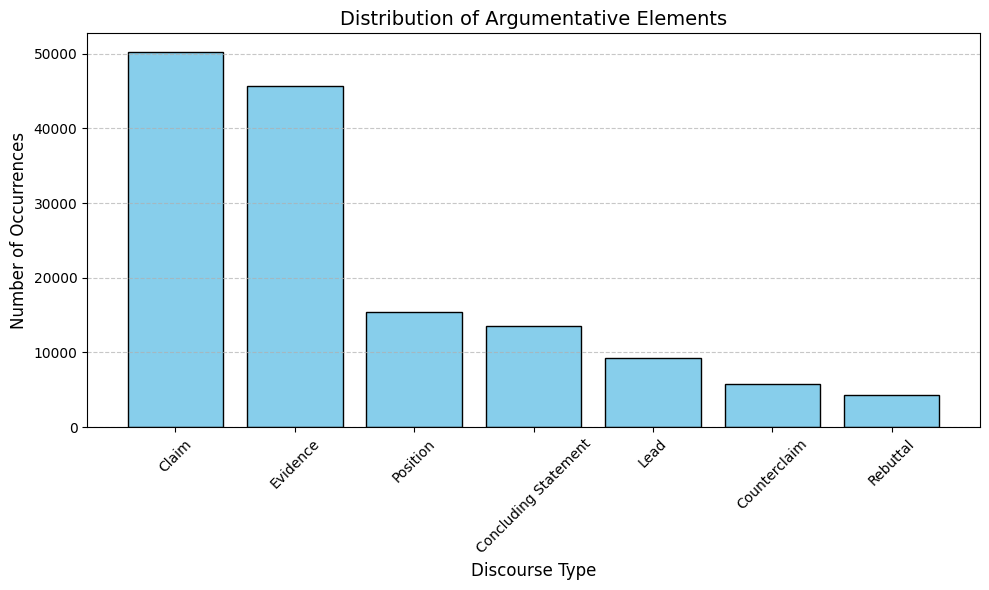

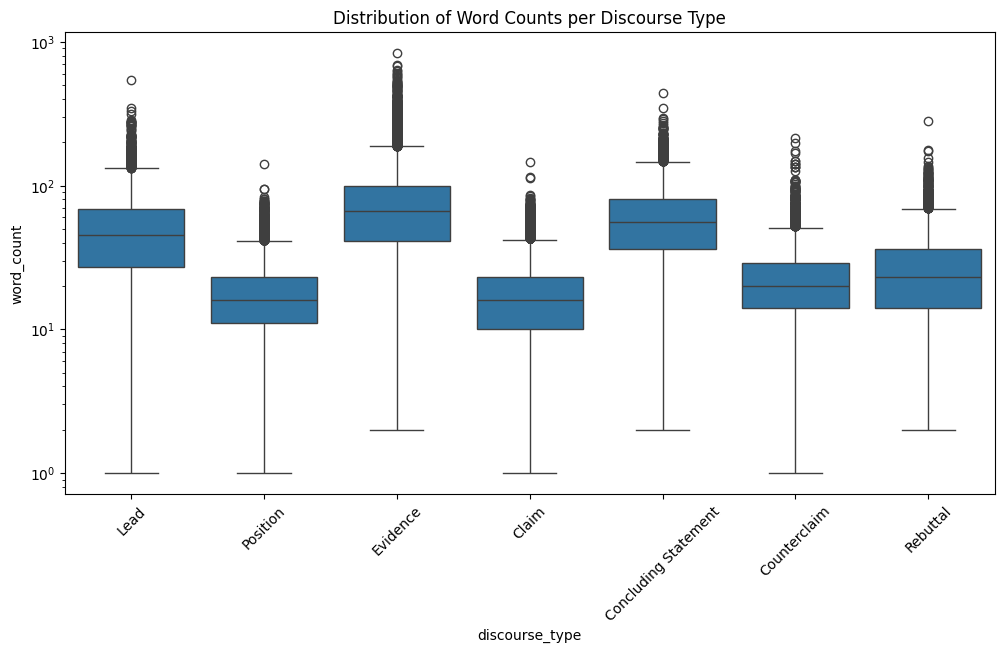

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Count the occurrences of each discourse type
type_counts = train['discourse_type'].value_counts().reset_index()
type_counts.columns = ['discourse_type', 'count']

# 2. Sort the counts for a cleaner bar chart
type_counts = type_counts.sort_values(by='count', ascending=False)

# 3. Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(type_counts['discourse_type'], type_counts['count'], color='skyblue', edgecolor='black')

# 4. Add labels and title
plt.xlabel('Discourse Type', fontsize=12)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.title('Distribution of Argumentative Elements', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('discourse_distribution.png')

# Create a word count column
train['word_count'] = train['discourse_text'].apply(lambda x: len(x.split()))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=train, x='discourse_type', y='word_count')
plt.title('Distribution of Word Counts per Discourse Type')
plt.yscale('log') # Use log scale if Evidence is much longer than others
plt.xticks(rotation=45)
plt.savefig('length_distribution.png')

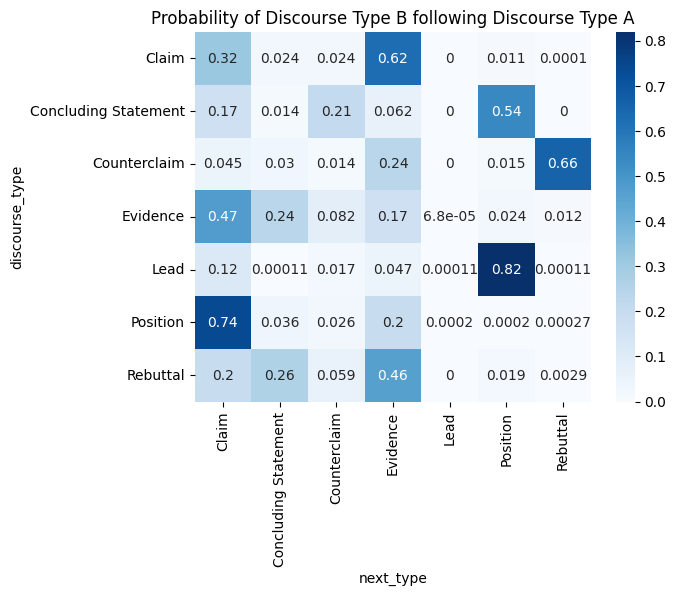

In [14]:
# This requires sorting the dataframe by 'id' and 'discourse_start'
train = train.sort_values(['id', 'discourse_start'])
train['next_type'] = train.groupby('id')['discourse_type'].shift(-1)

# Create a heatmap of transitions
transition_matrix = pd.crosstab(train['discourse_type'], train['next_type'], normalize='index')
sns.heatmap(transition_matrix, annot=True, cmap='Blues')
plt.title('Probability of Discourse Type B following Discourse Type A')
plt.savefig('transition_matrix.png')

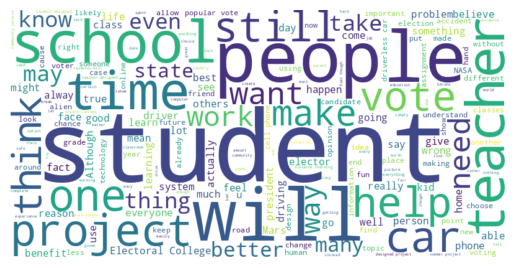

In [15]:
from wordcloud import WordCloud

# Example for 'Concluding Statement'
text = " ".join(train[train['discourse_type'] == 'Concluding Statement']['discourse_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.savefig('concluding_wordcloud.png')

# Example for 'Rebuttal'
text = " ".join(train[train['discourse_type'] == 'Rebuttal']['discourse_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.savefig('concluding_wordcloud.png')

In [16]:
#LSTM
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# vocab from texts
all_words = []
for text in ready_df['text']:
    all_words.extend(text.split())

word_counter = Counter(all_words)
vocab = {word: idx+2 for idx, (word, _) in enumerate(word_counter.most_common(50000))} # top 50k words
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1
print(f"Vocabulary size: {len(vocab)}")

# Label mapping
label_list = [
    'O',
    'B-Lead', 'I-Lead',
    'B-Position', 'I-Position',
    'B-Claim', 'I-Claim',
    'B-Counterclaim', 'I-Counterclaim',
    'B-Rebuttal', 'I-Rebuttal',
    'B-Evidence', 'I-Evidence',
    'B-Concluding Statement', 'I-Concluding Statement'
]
label_to_id = {label: idx for idx, label in enumerate(label_list)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

# our custom dataset
class EssayDataset(Dataset):
    def __init__(self, df, vocab, label_to_id, max_len=2048):
        self.vocab = vocab
        self.label_to_id = label_to_id
        self.max_len = max_len
        self.data = []

        for _, row in df.iterrows():
            words = row['text'].split()
            labels = row['labels']

            # Convert to indices
            word_ids = [vocab.get(w, vocab['<UNK>']) for w in words]
            label_ids = [label_to_id.get(l, 0) for l in labels] # 0 = O if missing

            # Truncate / pad
            if len(word_ids) > max_len:
                word_ids = word_ids[:max_len]
                label_ids = label_ids[:max_len]
            else:
                pad_len = max_len - len(word_ids)
                word_ids += [vocab['<PAD>']] * pad_len
                label_ids += [label_to_id['O']] * pad_len

            self.data.append((torch.tensor(word_ids), torch.tensor(label_ids)))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# Split data
train_df, val_df = train_test_split(ready_df, test_size=0.1, random_state=42)    #training

train_dataset = EssayDataset(train_df, vocab, label_to_id, max_len=2048)
val_dataset = EssayDataset(val_df, vocab, label_to_id)   #Training

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

Vocabulary size: 50002


In [17]:
class TestEssayDataset(Dataset):
    def __init__(self, test_folder, vocab, max_len=2048):
        self.vocab = vocab
        self.max_len = max_len
        self.data = []
        self.ids = []

        for test_file in sorted(test_folder.glob('*.txt')):
            essay_id = test_file.stem
            text = test_file.read_text(encoding='utf-8')
            words = text.split()

            word_ids = [vocab.get(w, vocab['<UNK>']) for w in words]

            # Pad or truncate
            if len(word_ids) > max_len:
                word_ids = word_ids[:max_len]
            else:
                pad_len = max_len - len(word_ids)
                word_ids += [vocab['<PAD>']] * pad_len

            self.data.append(torch.tensor(word_ids))
            self.ids.append(essay_id)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.ids[idx]

In [18]:
class DiscourseRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=2,
                 num_classes=len(label_list), dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            bidirectional=True, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes) # *2 because bidirectional

    def forward(self, x):
        embeds = self.embedding(x) # (batch, seq_len, embed_dim)
        lstm_out, _ = self.lstm(embeds) # (batch, seq_len, hidden*2)
        lstm_out = self.dropout(lstm_out)
        logits = self.fc(lstm_out) # (batch, seq_len, num_classes)
        return logits

model = DiscourseRNN(vocab_size=len(vocab))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(device)

cuda


In [19]:
criterion = nn.CrossEntropyLoss(ignore_index=label_to_id['O']) # optional: weight O less
optimizer = optim.Adam(model.parameters(), lr=1e-3)
def train_epoch(model, loader):
  model.train()
  total_loss = 0
  for inputs, targets in tqdm(loader):
    inputs, targets = inputs.to(device), targets.to(device)
    optimizer.zero_grad()
    outputs = model(inputs) # (batch, seq, classes)
    loss = criterion(outputs.view(-1, outputs.size(-1)), targets.view(-1))
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
  return total_loss / len(loader)

# Full training with checkpoints
for epoch in range(15):# increase as we need
  loss = train_epoch(model, train_loader)
  print(f"Epoch {epoch+1} - Loss: {loss:.4f}")

  torch.save({
      'epoch': epoch,
      'model_state_dict': model.state_dict(),
      'optimizer_state_dict': optimizer.state_dict(),
      'loss': loss,
  }, f"lstm_checkpoint_epoch_{epoch+1}.pth")
  print("CHeckpoint saved - safe to stop now")

100%|██████████| 439/439 [01:47<00:00,  4.07it/s]


Epoch 1 - Loss: 1.1039
CHeckpoint saved - safe to stop now


100%|██████████| 439/439 [01:47<00:00,  4.10it/s]


Epoch 2 - Loss: 0.7507
CHeckpoint saved - safe to stop now


100%|██████████| 439/439 [01:47<00:00,  4.10it/s]


...

Epoch 13 - Loss: 0.2868
CHeckpoint saved - safe to stop now


100%|██████████| 439/439 [01:46<00:00,  4.11it/s]


Epoch 14 - Loss: 0.2497
CHeckpoint saved - safe to stop now


100%|██████████| 439/439 [01:46<00:00,  4.11it/s]

Epoch 15 - Loss: 0.2172
CHeckpoint saved - safe to stop now


In [44]:
def evaluate_real(model, loader, name=""):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            preds = outputs.argmax(dim=-1)

            # Only evaluate on REAL discourse tokens (exclude class 0 which is 'O')
            mask = targets != 0

            if mask.sum().item() > 0:
                correct += (preds == targets ).sum().item()
                total += mask.sum().item()

    if total > 0:
        acc = correct / total
        print(f"{name} Accuracy (Real Discourse Only): {acc:.4f} ({correct}/{total})")
    else:
        print(f"No discourse tokens in {name}")

# Run both
evaluate_real(model, train_loader, name="Training")
evaluate_real(model, val_loader, name="Validation")

Training Accuracy (Real Discourse Only): 0.9493 (5349992/5635507)
Validation Accuracy (Real Discourse Only): 0.7544 (473843/628133)


In [47]:
from sklearn.metrics import f1_score
import numpy as np

def evaluate_f1(model, loader, name=""):
    model.eval()
    all_preds = [ ]
    all_targets = [ ]

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            preds = outputs.argmax(dim=-1)

            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(targets.cpu().numpy().flatten())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    # Calculate F1 only on real discourse tokens (exclude class 0 which is 'O')
    mask = all_targets != 0

    if mask.sum() > 0:
        f1 = f1_score(all_targets , all_preds , average='macro')
        print(f"{name} Macro F1 Score (Real Discourse Only): {f1:.4f}")

        # Per-class F1 (optional but very useful)
        per_class_f1 = f1_score(all_targets , all_preds , average=None)
        print(f"Per-class F1: {np.round(per_class_f1, 4)}")
    else:
        print(f"No discourse tokens in {name}")

# Run it on both
evaluate_f1(model, train_loader, name="Training")
evaluate_f1(model, val_loader, name="Validation")

Training Macro F1 Score (Real Discourse Only): 0.6585
Per-class F1: [0.     0.8094 0.9733 0.7465 0.8423 0.6052 0.8387 0.7393 0.846  0.6614
 0.8666 0.6684 0.2339 0.7298 0.3162]
Validation Macro F1 Score (Real Discourse Only): 0.4089
Per-class F1: [0.     0.7348 0.7849 0.5501 0.5187 0.3529 0.4495 0.3633 0.3782 0.3266
 0.3334 0.3674 0.2041 0.4804 0.2888]


In [48]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

def print_f1_results(model, loader, name=""):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=-1)

            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(targets.cpu().numpy().flatten())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    mask = all_targets != 0

    if mask.sum() == 0:
        print(f"No discourse tokens in {name}")
        return

    # Macro F1
    macro_f1 = f1_score(all_targets , all_preds , average='macro')

    # Per-class F1
    per_class_f1 = f1_score(all_targets , all_preds , average=None, labels=range(1,15))

    # Create nice table
    label_names = ['B-Lead','I-Lead','B-Position','I-Position','B-Claim','I-Claim',
                   'B-Counterclaim','I-Counterclaim','B-Rebuttal','I-Rebuttal',
                   'B-Evidence','I-Evidence','B-Concluding','I-Concluding']

    df = pd.DataFrame({
        'Label': label_names,
        'F1 Score': np.round(per_class_f1, 4)
    })

    print(f"\n=== {name} Results ===")
    print(f"Macro F1 Score: {macro_f1:.4f}\n")
    print(df.to_string(index=False))

# Run both
print_f1_results(model, train_loader, name="Training")
print_f1_results(model, val_loader, name="Validation")


=== Training Results ===
Macro F1 Score: 0.6585

         Label  F1 Score
        B-Lead    0.8094
        I-Lead    0.9733
    B-Position    0.7465
    I-Position    0.8423
       B-Claim    0.6052
       I-Claim    0.8387
B-Counterclaim    0.7393
I-Counterclaim    0.8460
    B-Rebuttal    0.6614
    I-Rebuttal    0.8666
    B-Evidence    0.6684
    I-Evidence    0.2339
  B-Concluding    0.7298
  I-Concluding    0.3162

=== Validation Results ===
Macro F1 Score: 0.4089

         Label  F1 Score
        B-Lead    0.7348
        I-Lead    0.7849
    B-Position    0.5501
    I-Position    0.5187
       B-Claim    0.3529
       I-Claim    0.4495
B-Counterclaim    0.3633
I-Counterclaim    0.3782
    B-Rebuttal    0.3266
    I-Rebuttal    0.3334
    B-Evidence    0.3674
    I-Evidence    0.2041
  B-Concluding    0.4804
  I-Concluding    0.2888
